# Tutorial 6 — A comparison harness: sweep, evaluate, rank

This tutorial assembles the v1.2 building blocks into one honest small-N evaluation:

1. **Feature discovery** across a grid of CPP configurations with `aa.CPPGrid`.
2. **Site-localization metrics** — per-protein AP (and a tolerant variant), detection@threshold, and a bootstrap CI (`aa.comp_per_protein_ap`, `aa.comp_detection_metrics`, `aa.comp_bootstrap_ci`).
3. **Peak-preserving smoothing** of a per-residue score track (`aa.comp_smooth_scores`).
4. A **per-protein rank plot** sanity check (`aa.plot_rank`).

## 1. Feature discovery — `CPPGrid` sweep

`CPPGrid` binds the dataset once and sweeps configurations across four stage-grouped param dicts. A `list` value is a swept axis; the grid is the Cartesian product. It returns the per-config feature tables plus a lightweight `df_params` summary (object axes as a position index, plus `n_warnings` / `n_errors`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import aaanalysis as aa

aa.options["verbose"] = False
df_seq = aa.load_dataset(name="DOM_GSEC", n=20)
labels = df_seq["label"].to_list()

cppg = aa.CPPGrid(df_seq=df_seq, labels=labels, n_jobs=1, random_state=0)
list_df_feat, df_params = cppg.run(
    params_split={"split_types": "Segment"},
    params_scales=aa.load_scales(top60_n=38),
    params_cpp={"n_filter": [25, 50]},
)
df_params

,split_types,n_filter,df_scales,n_warnings,n_errors
0,Segment,25,0,0,0
1,Segment,50,0,0,0


`df_params` is the map from configuration to result: each row aligns to `list_df_feat[i]`. Use `n_warnings` / `n_errors` to spot configs that under-deliver (e.g. `n_filter` larger than the config can generate) before trusting them downstream.

## 2. Site-localization metrics

These metrics score a per-residue predictor *per protein*. `DOM_GSEC` is a domain-level dataset, so for illustration we synthesize per-residue score tracks with known positive positions — in practice these come from your own per-residue scorer.

- **per-protein AP** ranks residues within each protein; the **tolerant** variant (`tolerance=k`) credits a hit within `k` residues (positional jitter).
- **detection metrics** answer "is the site actually *called*?" at a fixed threshold.
- **bootstrap CI** gives honest small-N uncertainty over the per-protein AP vector.

In [2]:
rng = np.random.default_rng(1)
list_scores, list_positions = [], []
for _ in range(15):
    L = int(rng.integers(50, 90))
    s = rng.random(L) * 0.7                       # background
    pos = sorted(rng.choice(L, size=int(rng.integers(1, 4)), replace=False).tolist())
    for p in pos:
        s[p] = min(1.0, s[p] + rng.uniform(0.05, 0.35))   # weak true-site signal
    list_scores.append(s)
    list_positions.append(pos)

ap = aa.comp_per_protein_ap(list_scores=list_scores, list_positions=list_positions)
ap_tol = aa.comp_per_protein_ap(list_scores=list_scores, list_positions=list_positions, tolerance=2)
det = aa.comp_detection_metrics(list_scores=list_scores, list_positions=list_positions, threshold=0.6)
ci = aa.comp_bootstrap_ci(values=ap, seed=0)

print(f"per-protein AP   : {np.mean(ap):.3f}  (95% CI {ci['ci_low']:.3f}-{ci['ci_high']:.3f})")
print(f"tolerant AP (k=2): {np.mean(ap_tol):.3f}")
print("detection@0.6   :", {k: round(float(v), 3) for k, v in det.items()})

per-protein AP   : 0.463  (95% CI 0.302-0.631)
tolerant AP (k=2): 0.587
detection@0.6   : {'recall': 0.469, 'precision': 0.093, 'f1': 0.155, 'mcc': 0.157, 'tp': 15.0, 'fp': 147.0, 'fn': 17.0, 'tn': 922.0}


## 3. Peak-preserving smoothing

Windowed predictions jitter by a residue or two. `aa.comp_smooth_scores` smooths a per-residue track (triangular / gaussian) but takes `max(smoothed, raw)` so true peaks are never attenuated.

In [3]:
track = list_scores[0]
smoothed = aa.comp_smooth_scores(scores=track, method="triangular", window=2)
print("raw peak   :", round(float(np.max(track)), 3))
print("smoothed pk:", round(float(np.max(smoothed)), 3), "(>= raw peak by construction)")

raw peak   : 0.882
smoothed pk: 0.882 (>= raw peak by construction)


## 4. Per-protein rank plot

Finally, the deployed-predictor sanity check: each protein's max score vs its rank, colored by group, with the deployment threshold drawn in.

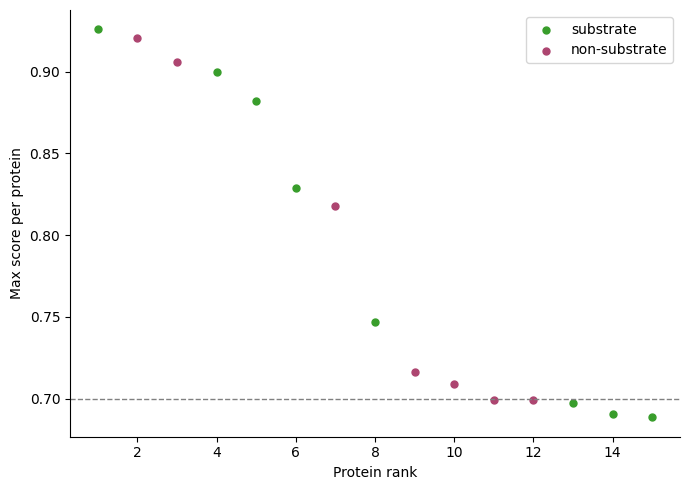

In [4]:
df_rank = pd.DataFrame({
    "score": [float(s.max()) for s in list_scores],
    "group": ["substrate"] * 8 + ["non-substrate"] * 7,
})
fig, ax = aa.plot_rank(df_rank=df_rank, threshold=0.7)
plt.tight_layout()
plt.show()

**Takeaway.** `CPPGrid` discovers features across a config grid; the `aa.metrics` functions + `comp_smooth_scores` quantify per-site performance with honest CIs; `aa.plot_rank` is the one-glance deployment check. Swap the illustrative per-residue tracks for your own scorer's output to run this end-to-end.